# Prédiction de la pauvreté des ménages en RDC

## 🎯 Objectif

Ce notebook a pour objectif de construire un modèle de prédiction de la pauvreté des ménages à partir des données ECVM 2024 (RDC).

La variable cible `nivie` représente le niveau de vie du ménage et est de nature catégorielle. Elle est donc recodée en variable binaire :

- 1 = Pauvre  
- 0 = Non Pauvre  

Le problème est ainsi traité comme un problème de **classification binaire**.

---

## Approche méthodologique

Le pipeline suivi dans ce notebook est le suivant :

1. Chargement des bases de données :
   - `welfare` (base principale)
   - `menage`
   - `individu`

2. Vérification des identifiants et fusion des bases

3. Construction de variables explicatives :
   - Variables issues de `welfare`
   - Variables issues de `menage`
   - Agrégats construits à partir de `individu` (ex : âge moyen, part de femmes, etc.)

4. Construction de la variable cible binaire (`pauvre_bin`)

5. Construction d’un poids normalisé :
   - `poids_normalise = (hhweight × N) / somme(hhweight)`

6. Analyse descriptive et tests statistiques

7. Préparation des données (imputation, encodage, normalisation)

8. Entraînement et comparaison de plusieurs modèles :
   - Régression logistique (modèle classique)
   - Random Forest Classifier
   - Gradient Boosting Classifier

9. Évaluation des modèles avec :
   - Accuracy
   - Precision
   - Recall
   - F1-score
   - ROC-AUC

10. Sélection du meilleur modèle

---

## Utilisation du modèle

Le modèle ayant les meilleures performances est :

- réentraîné sur l’ensemble des données ;
- sauvegardé au format `.pkl` avec `joblib`.

Ce modèle est ensuite utilisé dans une **application Streamlit** permettant de :

- saisir les caractéristiques d’un ménage ;
- prédire en temps réel la probabilité d’être pauvre.

---

## ⚠️ Remarques importantes

- Les variables binaires (Oui / Non) sont converties en 0 / 1 avant la modélisation.
- Les variables catégorielles sont encodées automatiquement via OneHotEncoder.
- Les poids normalisés sont utilisés dans les analyses descriptives et la modélisation lorsque le modèle accepte des poids d’échantillonnage. d’enquête sont pris en compte dans le modèle classique et, lorsque possible, dans les modèles de machine learning.
- Les résultats dépendent de la qualité et de la complétude des données.

---

## 📌 Reproductibilité

Pour exécuter ce notebook :

1. Vérifier le chemin du dossier contenant les données
2. Installer les dépendances (requirements.txt)
3. Lancer toutes les cellules dans l’ordre

---

## Extension du projet

Ce notebook constitue la base analytique du projet.

Le modèle final est intégré dans une application Streamlit pour une utilisation opérationnelle.

## Plan de lecture du notebook
- **Sections 1 à 11** : préparation et structuration des données
- **Sections 12 à 16** : diagnostic, description et tests statistiques
- **Sections 17 à 21** : préparation de la modélisation et comparaison des modèles
- **Sections 22 à 27** : interprétation, validation, sauvegarde et synthèse finale

In [1]:
# ==========================================================
# 0. IMPORTATION DES LIBRAIRIES
# ==========================================================
# Cette cellule charge toutes les bibliothèques nécessaires.
# Elles servent à :
# - manipuler les données (pandas, numpy)
# - faire des graphiques (matplotlib)
# - réaliser des tests statistiques (scipy)
# - préparer les données et entraîner les modèles (scikit-learn)

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Paramètres d'affichage pour mieux lire les tableaux
pd.set_option("display.max_columns", 300)
pd.set_option("display.max_rows", 300)
pd.set_option("display.width", 200)


## 1. Définition des chemins de travail

Cette section indique où se trouvent :
- les bases de données `.dta`
- les dictionnaires `.xlsx`

Le dossier `folder` doit être adapté si les données ne se trouvent pas au même endroit sur un autre ordinateur.

In [2]:
# ==========================================================
# 1. CHEMINS DES DONNEES
# ==========================================================
folder = r"C:\Users\LENOVO\Desktop\memoire\data"

files = {
    "individu": "ecvm_individu_rdc_2024.dta",
    "menage": "ecvm_menage_rdc_2024.dta",
    "welfare": "ecvm_welfare_rdc_2024.dta"
}

dict_files = {
    "individu": "dictionnaire_individu.xlsx",
    "menage": "dictionnaire_menage.xlsx",
    "welfare": "dictionnaire_welfare.xlsx"
}

## 2. Chargement des bases

On charge les trois bases principales :
- `welfare` : base principale du modèle
- `menage` : variables complémentaires au niveau ménage
- `individu` : variables individuelles à agréger ensuite au niveau ménage

On essaie aussi de charger les dictionnaires de variables.  
Ces dictionnaires servent à documenter les colonnes, mais le notebook peut fonctionner même si la lecture des fichiers Excel échoue.

In [3]:
# ==========================================================
# 2. CHARGEMENT DES BASES ET DICTIONNAIRES
# ==========================================================
bases = {}
dictionnaires = {}

# Lecture des bases Stata
for nom, file in files.items():
    path = os.path.join(folder, file)
    print(f"Chargement de {nom} : {path}")
    bases[nom] = pd.read_stata(path, convert_categoricals=True)

# Lecture optionnelle des dictionnaires Excel
for nom, file in dict_files.items():
    path = os.path.join(folder, file)
    if os.path.exists(path):
        try:
            dictionnaires[nom] = pd.read_excel(path)
            print(f"Dictionnaire chargé : {nom}")
        except Exception as e:
            print(f"Lecture du dictionnaire impossible pour {nom} : {e}")

# Création d'objets distincts pour plus de clarté
df_individu = bases["individu"].copy()
df_menage = bases["menage"].copy()
df_welfare = bases["welfare"].copy()

print("\nDimensions des bases :")
print("individu :", df_individu.shape)
print("menage   :", df_menage.shape)
print("welfare  :", df_welfare.shape)

Chargement de individu : C:\Users\LENOVO\Desktop\memoire\data\ecvm_individu_rdc_2024.dta
Chargement de menage : C:\Users\LENOVO\Desktop\memoire\data\ecvm_menage_rdc_2024.dta
Chargement de welfare : C:\Users\LENOVO\Desktop\memoire\data\ecvm_welfare_rdc_2024.dta
Dictionnaire chargé : individu
Dictionnaire chargé : menage
Dictionnaire chargé : welfare

Dimensions des bases :
individu : (120476, 56)
menage   : (24522, 43)
welfare  : (24521, 42)


## 3. Vérification des identifiants

Avant toute fusion, il faut vérifier que les colonnes servant d’identifiants existent réellement.

D'après le travail méthodologique retenu :
- `welfare` et `individu` se relient par : `grappe`, `menage`, `hhid`
- `menage` se relie à `welfare` par : `grappe`, `menage`

Cette étape permet de sécuriser les fusions.

In [4]:
# ==========================================================
# 3. VERIFICATION DES IDENTIFIANTS
# ==========================================================
for nom, df in {"individu": df_individu, "menage": df_menage, "welfare": df_welfare}.items():
    print(f"\n--- {nom.upper()} ---")
    for key in ["grappe", "garppe", "menage", "hhid"]:
        print(f"{key} -> {key in df.columns}")


--- INDIVIDU ---
grappe -> True
garppe -> False
menage -> True
hhid -> True

--- MENAGE ---
grappe -> True
garppe -> False
menage -> True
hhid -> True

--- WELFARE ---
grappe -> True
garppe -> False
menage -> True
hhid -> True


## 4. Paramétrage du projet

Cette cellule centralise les principaux choix méthodologiques :
- nom de la cible brute
- nom de la cible binaire
- identifiants
- poids
- variables explicatives retenues
- variables à aller chercher dans `menage`
- agrégats à construire à partir de `individu`

Le fait de regrouper ces paramètres au même endroit permet de modifier plus facilement le notebook par la suite.

In [5]:
# ==========================================================
# 4. PARAMETRAGE
# ==========================================================
TARGET_RAW = "nivie"          # cible telle qu'elle existe dans la base
TARGET_BIN = "pauvre_bin"     # cible recodée en 0/1

# Identifiants de fusion
ID_WELFARE_INDIV = ["grappe", "menage", "hhid"]
ID_MENAGE = ["grappe", "menage"]

# Variables de pondération
WEIGHT_VAR = "hhweight"
HH_SIZE_VAR = "hhsize"

# Variables retenues dans welfare :
# on exploite d'abord les caractéristiques déjà disponibles dans la base principale
WELFARE_FEATURES = [
    "hage", "hgender", "hmar", "hreligion", "heduc", "hdiploma",
    "hactiv12m", "hactiv7j", "hbranch", "hcsp", "handig",
    "hhsize", "typmen", "milieu", "ratio_dependance"
]

# Variables complémentaires à récupérer dans la base menage
MENAGE_RENAME_MAP = {
    "logem": "logem",       # statut d'occupation du logement
    "elec_ac": "elec_ac",   # accès à l'électricité
    "toilet": "toilet",     # présence de toilettes saines
    "telpor": "telpor"      # possession d'un téléphone portable
}

# Agrégats construits depuis la base individu
# Le principe : résumer les individus d'un ménage en une seule ligne ménage
INDIVIDU_AGG_SPECS = {
    "part_ayant_compte_bancaire": {"source": "bank", "agg": "proportion_modalite", "modalite": "Oui"},
    "part_ayant_handicap_majeur": {"source": "handig", "agg": "proportion_modalite", "modalite": "Oui"},
    "nb_modalites_instruction": {"source": "educ_hi", "agg": "n_unique"}
}
#Les variables individuelles ont été agrégées au niveau du ménage afin de construire des indicateurs synthétiques. Ces agrégations incluent notamment des proportions (ex : part des individus ayant un compte bancaire) et des mesures de diversité (ex : nombre de niveaux d’instruction différents au sein du ménage).

## 5. Fonctions utilitaires

On définit ici des fonctions qui seront réutilisées dans plusieurs étapes :

- `existing_columns` : garde seulement les variables réellement présentes
- `safe_select_existing` : évite les erreurs si une colonne n’existe pas
- `weighted_proportion` : calcule une proportion pondérée
- `build_individu_aggregates` : construit les agrégats individu → ménage

L’objectif est de rendre le notebook plus robuste et plus lisible.

In [6]:
# ==========================================================
# 5. FONCTIONS UTILITAIRES
# ==========================================================
def existing_columns(df, cols):
    """Retourne uniquement les colonnes présentes dans le DataFrame."""
    return [c for c in cols if c in df.columns]

def safe_select_existing(mapping_dict, df):
    """Retourne les variables du dictionnaire uniquement si elles existent."""
    return {k: v for k, v in mapping_dict.items() if v in df.columns}

def weighted_proportion(x, w):
    """Calcule une proportion pondérée pour une variable binaire 0/1."""
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")
    mask = x.notna() & w.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])

def weighted_mean(x, w):
    """Calcule une moyenne pondérée."""
    x = pd.to_numeric(x, errors="coerce")
    w = pd.to_numeric(w, errors="coerce")
    mask = x.notna() & w.notna()
    if mask.sum() == 0:
        return np.nan
    return np.average(x[mask], weights=w[mask])

def build_individu_aggregates(df_individu, id_cols, agg_specs):
    """
    Construit des variables agrégées au niveau ménage à partir de la base individu.

    Exemple :
    - part de membres ayant un compte bancaire
    - part de membres ayant un handicap majeur
    - diversité des niveaux d'instruction
    """
    if not agg_specs:
        return None

    grouped = df_individu.groupby(id_cols, dropna=False)
    pieces = []

    for new_var, spec in agg_specs.items():
        source = spec["source"]
        agg = spec["agg"]

        if source not in df_individu.columns:
            print(f"[Ignorée] {source} absent de df_individu.")
            continue

        if agg == "mean":
            tmp = grouped[source].mean().rename(new_var)
        elif agg == "sum":
            tmp = grouped[source].sum().rename(new_var)
        elif agg == "max":
            tmp = grouped[source].max().rename(new_var)
        elif agg == "min":
            tmp = grouped[source].min().rename(new_var)
        elif agg == "n_unique":
            tmp = grouped[source].nunique().rename(new_var)
        elif agg == "proportion_modalite":
            modalite = str(spec["modalite"])
            tmp = grouped[source].apply(lambda s: (s.astype(str) == modalite).mean()).rename(new_var)
        else:
            print(f"[Ignorée] Méthode inconnue pour {new_var}.")
            continue

        pieces.append(tmp.reset_index())

    if not pieces:
        return None

    out = pieces[0]
    for p in pieces[1:]:
        out = out.merge(p, on=id_cols, how="outer")
    return out

def build_dependency_ratio(df_individu, id_cols, age_col="age"):
    """
    Calcule le ratio de dépendance :
    (membres de moins de 15 ans + membres de 65 ans et plus) / membres de 15 à 64 ans
    """
    if age_col not in df_individu.columns:
        print(f"[Ignorée] {age_col} absent de df_individu : ratio_dependance non calculé.")
        return None

    tmp = df_individu[id_cols + [age_col]].copy()
    tmp[age_col] = pd.to_numeric(tmp[age_col], errors="coerce")

    grouped = tmp.groupby(id_cols, dropna=False)

    dep = grouped[age_col].apply(lambda s: ((s < 15) | (s >= 65)).sum())
    actifs = grouped[age_col].apply(lambda s: ((s >= 15) & (s < 65)).sum())

    ratio = (dep / actifs.replace(0, np.nan)).rename("ratio_dependance").reset_index()
    return ratio

def build_class_balance_weights(y):
    """Construit des poids de classes équilibrés à partir de y."""
    y = pd.Series(y)
    counts = y.value_counts(dropna=False)
    valid_counts = counts[counts > 0]
    if valid_counts.empty:
        raise ValueError("Impossible de calculer les poids de classes : y est vide.")
    n_classes = len(valid_counts)
    total = valid_counts.sum()
    return {cls: total / (n_classes * cnt) for cls, cnt in valid_counts.items()}

def combine_weights(base_weights, y):
    """Combine poids d'enquête et poids d'équilibrage des classes."""
    class_weights = build_class_balance_weights(y)
    y_series = pd.Series(y, index=base_weights.index)
    class_component = y_series.map(class_weights).astype(float)
    combined = pd.to_numeric(base_weights, errors="coerce") * class_component
    return combined, class_weights

def fit_pipeline_with_weights(pipe, X_train, y_train, w_train):
    """Entraîne un pipeline en transmettant les poids au modèle final."""
    return pipe.fit(X_train, y_train, model__sample_weight=w_train)

def evaluate_classification(y_true, y_pred, y_prob, model_name):
    """Retourne les principaux indicateurs de performance d'un classifieur."""
    return {
        "modele": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) == 2 else np.nan
    }


## 6. Construction des agrégats individu

Cette étape est essentielle.

### Pourquoi ?
La base `individu` contient **une ligne par personne**, alors que la modélisation se fait au **niveau du ménage**.

Il faut donc résumer les informations individuelles en indicateurs ménage, par exemple :
- âge moyen des membres du ménage
- proportion de femmes
- proportion de membres bancarisés

À la fin, on obtient une table agrégée qui pourra être fusionnée avec `welfare`.

In [7]:
# ==========================================================
# 6. CONSTRUCTION DES AGREGATS INDIVIDU
# ==========================================================
agg_individu = build_individu_aggregates(df_individu, ID_WELFARE_INDIV, INDIVIDU_AGG_SPECS)
dependency_ratio = build_dependency_ratio(df_individu, ID_WELFARE_INDIV, age_col="age")

if agg_individu is not None and dependency_ratio is not None:
    agg_individu = agg_individu.merge(dependency_ratio, on=ID_WELFARE_INDIV, how="outer")
elif dependency_ratio is not None:
    agg_individu = dependency_ratio.copy()

if agg_individu is not None:
    print("Aperçu des agrégats individu :")
    display(agg_individu.head())
else:
    print("Aucun agrégat individu construit.")


Aperçu des agrégats individu :


,grappe,menage,hhid,part_ayant_compte_bancaire,part_ayant_handicap_majeur,nb_modalites_instruction,ratio_dependance
0,1,1,1001.0,0.400000,0.0,2,0.25
1,1,2,1002.0,0.666667,0.0,2,0.00
2,1,3,1003.0,0.750000,0.0,1,0.00
3,1,4,1004.0,0.750000,0.0,2,0.00
4,1,5,1005.0,0.500000,0.0,2,0.20


## 7. Préparation de la base ménage

On extrait ici de `menage` uniquement les variables utiles au modèle.

L’objectif est de :
- éviter de fusionner inutilement toute la base
- garder uniquement les colonnes pertinentes
- préparer une base plus légère et plus lisible

In [8]:
# ==========================================================
# 7. PREPARATION DE MENAGE
# ==========================================================
selected_menage = safe_select_existing(MENAGE_RENAME_MAP, df_menage)
cols_menage = list(dict.fromkeys(ID_MENAGE + list(selected_menage.values())))
df_menage_small = df_menage[cols_menage].copy()

rename_back = {v: k for k, v in selected_menage.items()}
df_menage_small = df_menage_small.rename(columns=rename_back)

print("Variables récupérées depuis menage :")
print(df_menage_small.columns.tolist())
display(df_menage_small.head())

Variables récupérées depuis menage :
['grappe', 'menage', 'logem', 'elec_ac', 'toilet', 'telpor']


,grappe,menage,logem,elec_ac,toilet,telpor
0,1.0,1.0,Locataire,Oui,Oui,Oui
1,1.0,2.0,Locataire,Oui,Oui,Oui
2,1.0,3.0,Locataire,Oui,Oui,Oui
3,1.0,4.0,Locataire,Oui,Oui,Oui
4,1.0,5.0,Locataire,Oui,Oui,Oui


## 8. Fusion des bases

On construit ici la base finale de travail :

1. `welfare` sert de base principale
2. on y ajoute les variables utiles de `menage`
3. on y ajoute les agrégats issus de `individu`

Cette étape doit être faite avec prudence car une mauvaise fusion peut créer des doublons ou des incohérences.

In [9]:
# ==========================================================
# 8. FUSION DES BASES
# ==========================================================
df_model = df_welfare.copy()

# Ajout des variables ménage
df_model = df_model.merge(
    df_menage_small,
    on=ID_MENAGE,
    how="left",
    validate="m:1"
)

# Ajout des agrégats individu
if agg_individu is not None:
    df_model = df_model.merge(
        agg_individu,
        on=ID_WELFARE_INDIV,
        how="left",
        validate="m:1"
    )

# Harmonisation de certains noms de variables pour la modélisation
alias_candidates = {
    "hmar": ["hmar", "hmstat"],
    "handig": ["handig", "hhandig"]
}

for target_col, candidates in alias_candidates.items():
    if target_col not in df_model.columns:
        for candidate in candidates:
            if candidate in df_model.columns:
                df_model[target_col] = df_model[candidate]
                break

print("Dimensions après fusion :", df_model.shape)
display(df_model.head())


Dimensions après fusion : (24521, 52)


,country,year,hhid,grappe,menage,province,milieu,hhweight,hhsize,eqadu1,eqadu2,hgender,hage,hmstat,hreligion,hnation,halfa,heduc,hdiploma,hhandig,hactiv7j,hactiv12m,hbranch,hsectins,hcsp,dali,dnal,dtot,pcexp,zregmil,zref,def_spa,def_temp,zali0,alpha0_min,alpha0_max,zali,alpha_min,alpha_max,nivie,typmen,quintet,logem,elec_ac,toilet,telpor,part_ayant_compte_bancaire,part_ayant_handicap_majeur,nb_modalites_instruction,ratio_dependance,hmar,handig
0,rdc,2024,1001.0,1,1,Kinshasa,Urbain,56.98615,5,4.17,3.008368,Masculin,62.0,Marié(e) monogame,Catholique,Congolaise,Oui,Superieur,Licence/Maitrise LMD/doctorat en medecine,Non,Occupe,Occupe,Aut. services,Etat/Collectivités locales,Ouvrier ou employé qualifié,1.130571e+07,2.809320e+07,39398908.0,4792941.00,3408556.0,2073281.875,1.644039,1.003205,1.152023e+06,0.603702,0.45391,1.604896e+06,0.468834,0.368117,Non Pauvre,Nucleaire strict,5,Locataire,Oui,Oui,Oui,0.400000,0.0,2,0.25,Marié(e) monogame,Non
1,rdc,2024,1002.0,1,2,Kinshasa,Urbain,56.98615,6,4.73,3.716393,Masculin,63.0,Marié(e) monogame,Protestant,Congolaise,Oui,Superieur,Licence/Maitrise LMD/doctorat en medecine,Non,Occupe,Occupe,Aut. services,Etat/Collectivités locales,Ouvrier ou employé qualifié,9.600014e+06,3.525385e+07,44853864.0,4547121.00,3408556.0,2073281.875,1.644039,1.003205,1.152023e+06,0.603702,0.45391,1.604896e+06,0.468834,0.368117,Non Pauvre,Nucleaire strict,5,Locataire,Oui,Oui,Oui,0.666667,0.0,2,0.00,Marié(e) monogame,Non
2,rdc,2024,1003.0,1,3,Kinshasa,Urbain,56.98615,4,3.18,2.768379,Féminin,59.0,Divorcé(e),Eglise de reveil,Congolaise,Oui,Superieur,Graduat/Licence LMD,Non,Occupe,Occupe,Aut. services,Etat/Collectivités locales,Cadre moyen/agent de maîtrise,1.059614e+07,1.902356e+07,29619698.0,4504105.50,3408556.0,2073281.875,1.644039,1.003205,1.152023e+06,0.603702,0.45391,1.604896e+06,0.468834,0.368117,Non Pauvre,Monoparental strict,5,Locataire,Oui,Oui,Oui,0.750000,0.0,1,0.00,Divorcé(e),Non
3,rdc,2024,1004.0,1,4,Kinshasa,Urbain,56.98615,4,3.52,2.607103,Masculin,50.0,Marié(e) monogame,Catholique,Congolaise,Oui,Superieur,Licence/Maitrise LMD/doctorat en medecine,Non,Occupe,Occupe,Aut. services,Entreprise publique/parapublique,Cadre moyen/agent de maîtrise,1.451806e+07,3.026617e+07,44784224.0,6810092.00,3408556.0,2073281.875,1.644039,1.003205,1.152023e+06,0.603702,0.45391,1.604896e+06,0.468834,0.368117,Non Pauvre,Nucleaire strict,5,Locataire,Oui,Oui,Oui,0.750000,0.0,2,0.00,Marié(e) monogame,Non
4,rdc,2024,1005.0,1,5,Kinshasa,Urbain,56.98615,6,4.86,3.560455,Masculin,62.0,Marié(e) monogame,Eglise de reveil,Congolaise,Oui,Superieur,Licence/Maitrise LMD/doctorat en medecine,Non,Occupe,Occupe,Aut. services,Etat/Collectivités locales,Ouvrier ou employé qualifié,1.119925e+07,2.922119e+07,40420440.0,4097676.75,3408556.0,2073281.875,1.644039,1.003205,1.152023e+06,0.603702,0.45391,1.604896e+06,0.468834,0.368117,Non Pauvre,Nucleaire strict,5,Locataire,Oui,Oui,Oui,0.500000,0.0,2,0.20,Marié(e) monogame,Non


## 9. Vérification des doublons et construction de la cible

### Vérification des doublons
Il est important de s’assurer qu’après fusion, chaque ménage reste représenté une seule fois.

### Construction de la cible
La variable `nivie` est recodée en :
- `1 = Pauvre`
- `0 = Non Pauvre`

Ce recodage permet d’utiliser des modèles de classification.

In [10]:
# ==========================================================
# 9. CIBLE BINAIRE ET CONTROLE DES DOUBLONS
# ==========================================================
dup_count = df_model.duplicated(subset=ID_WELFARE_INDIV).sum()
print("Nombre de doublons sur les identifiants ménage :", dup_count)

if TARGET_RAW not in df_model.columns:
    raise ValueError(f"La variable cible brute '{TARGET_RAW}' est absente.")

df_model[TARGET_RAW] = df_model[TARGET_RAW].astype(str).str.strip()

mapping_target = {
    "Pauvre": 1,
    "Non Pauvre": 0
}

df_model[TARGET_BIN] = df_model[TARGET_RAW].map(mapping_target)

print("Répartition de la cible brute :")
display(df_model[TARGET_RAW].value_counts(dropna=False))

print("Répartition de la cible binaire :")
display(df_model[TARGET_BIN].value_counts(dropna=False))

Nombre de doublons sur les identifiants ménage : 0
Répartition de la cible brute :


nivie
Pauvre        14972
Non Pauvre     9549
Name: count, dtype: int64

Répartition de la cible binaire :


pauvre_bin
1    14972
0     9549
Name: count, dtype: int64

## 10. Construction du poids normalisé

On calcule ici une pondération normalisée à partir du poids d’enquête du ménage.

La formule retenue est :

`poids_normalise = (hhweight × N) / somme(hhweight)`

avec :
- `hhweight` = poids du ménage
- `N` = nombre total de ménages avec un poids non manquant
- `somme(hhweight)` = somme des poids

Cette pondération sera utilisée :
- dans les analyses descriptives pondérées
- dans le modèle classique pondéré
- et, lorsque c’est possible, dans les modèles de machine learning


In [12]:
# ==========================================================
# 10. CONSTRUCTION DU POIDS NORMALISÉ
# Formule : poids_normalise_i = (poids_i * N) / somme(poids_i)
# ==========================================================

if WEIGHT_VAR not in df_model.columns:
    raise ValueError(f"La variable de poids '{WEIGHT_VAR}' est absente de df_model.")

df_model[WEIGHT_VAR] = pd.to_numeric(df_model[WEIGHT_VAR], errors="coerce")

# Nombre total de ménages ayant un poids non manquant
N = df_model[WEIGHT_VAR].notna().sum()

# Somme des poids
somme_poids = df_model[WEIGHT_VAR].sum(skipna=True)

if pd.isna(somme_poids) or somme_poids == 0:
    raise ValueError("La somme des poids est nulle ou manquante.")

# Calcul du poids normalisé
df_model["poids_normalise"] = (df_model[WEIGHT_VAR] * N) / somme_poids

# Vérification
print("Nombre total de ménages (N) =", N)
print("Somme des poids normalisés =", df_model["poids_normalise"].sum())

print("Résumé des poids :")
display(df_model[[WEIGHT_VAR, "poids_normalise"]].describe())


Nombre total de ménages (N) = 24521
Somme des poids normalisés = 24520.999999999996
Résumé des poids :


,hhweight,poids_normalise
count,24521.000000,24521.000000
mean,803.215686,1.000000
std,696.616781,0.867285
min,3.753369,0.004673
25%,342.076917,0.425884
50%,638.955143,0.795496
75%,1087.532901,1.353974
max,5472.632749,6.813404


## 11. Sélection des variables explicatives

On rassemble ici toutes les variables qui pourront servir à la prédiction :
- variables de `welfare`
- variables de `menage`
- variables agrégées depuis `individu`

Cette étape produit la base d’analyse principale.

In [13]:
# ==========================================================
# 11. SÉLECTION DES VARIABLES EXPLICATIVES
# ==========================================================
welfare_features_existing = existing_columns(df_model, WELFARE_FEATURES)
menage_features_existing = [c for c in df_menage_small.columns if c not in ID_MENAGE]
indiv_features_existing = [c for c in agg_individu.columns if c not in ID_WELFARE_INDIV] if agg_individu is not None else []

feature_cols = welfare_features_existing + menage_features_existing + indiv_features_existing
feature_cols = [c for c in feature_cols if c not in [TARGET_RAW, TARGET_BIN]]

# Variables explicitement exclues à la demande
excluded_features = [
    "part_hommes",
    "part_femmes",
    "age_moyen_membres",
    "age_moyen_premier_mariage",
    "nb_modalites_instruction",
    "hactiv7j",
    "part_ayant_handicap_majeur",
    "hdiploma"
]
feature_cols = [c for c in feature_cols if c not in excluded_features]
feature_cols = list(dict.fromkeys(feature_cols))

analysis_cols = (
    ID_WELFARE_INDIV
    + [TARGET_RAW, TARGET_BIN, WEIGHT_VAR, HH_SIZE_VAR, "poids_normalise"]
    + feature_cols
)
analysis_cols = [c for c in analysis_cols if c in df_model.columns]

df_analysis = df_model[analysis_cols].copy()
df_analysis = df_analysis.loc[:, ~df_analysis.columns.duplicated()]

print("Base d'analyse :", df_analysis.shape)
display(pd.DataFrame({"variable_explicative": feature_cols}))


Base d'analyse : (24521, 25)


,variable_explicative
0,hage
1,hgender
2,hmar
3,hreligion
4,heduc
5,hactiv12m
6,hbranch
7,hcsp
8,handig
9,hhsize


In [14]:
df_analysis = df_analysis.loc[:, ~df_analysis.columns.duplicated()]

## 12. Diagnostic des valeurs manquantes

Avant toute modélisation, il faut savoir quelles variables comportent des valeurs manquantes.

Cela permet :
- d’anticiper l’imputation
- de repérer les variables trop incomplètes
- de documenter la qualité des données

In [15]:
# ==========================================================
# 12. ANALYSE DES VALEURS MANQUANTES
# ==========================================================
missing_table = (
    df_analysis.isna().mean()
    .sort_values(ascending=False)
    .rename("part_manquante")
    .reset_index()
    .rename(columns={"index": "variable"})
)

display(missing_table)

,variable,part_manquante
0,ratio_dependance,0.024428
1,hage,0.000082
2,hreligion,0.000041
3,grappe,0.000000
4,menage,0.000000
5,pauvre_bin,0.000000
6,hhweight,0.000000
7,nivie,0.000000
8,hhid,0.000000
9,poids_normalise,0.000000


## 13. Analyse descriptive de la pauvreté

Cette section permet de décrire la cible :
- répartition non pondérée
- répartition pondérée
- taux de pauvreté pondéré

On produit également un graphique simple pour visualiser la distribution des ménages pauvres et non pauvres.

In [16]:
# ==========================================================
# 13. ANALYSE DESCRIPTIVE DE LA PAUVRETE
# ==========================================================
if "poids_normalise" not in df_analysis.columns:
    raise ValueError("La colonne 'poids_normalise' est absente de df_analysis. Calcule d'abord les poids normalisés.")

print("Répartition non pondérée :")
display(df_analysis[TARGET_RAW].value_counts(dropna=False))

print("Répartition en pourcentage non pondéré :")
display((df_analysis[TARGET_RAW].value_counts(normalize=True, dropna=False) * 100).rename("pourcentage"))

table_ponderee = (
    df_analysis
    .dropna(subset=[TARGET_RAW, "poids_normalise"])
    .groupby(TARGET_RAW)["poids_normalise"]
    .sum()
    .pipe(lambda s: 100 * s / s.sum())
    .reset_index(name="pourcentage_pondere")
)

print("Répartition pondérée :")
display(table_ponderee)

taux_pauvrete_pondere = weighted_proportion(
    df_analysis[TARGET_BIN],
    df_analysis["poids_normalise"]
)
print("Taux de pauvreté pondéré :", taux_pauvrete_pondere)

# Statistiques descriptives enrichies sur les variables numériques retenues
numeric_features_desc = [
    c for c in feature_cols
    if c in df_analysis.columns and pd.api.types.is_numeric_dtype(df_analysis[c])
]

if numeric_features_desc:
    desc_non_pond = df_analysis[numeric_features_desc].describe().T
    desc_non_pond["median"] = df_analysis[numeric_features_desc].median()
    desc_non_pond["missing_rate"] = df_analysis[numeric_features_desc].isna().mean()
    print("\nStatistiques descriptives non pondérées des variables numériques :")
    display(desc_non_pond)

    desc_pond = pd.DataFrame({
        "variable": numeric_features_desc,
        "moyenne_ponderee": [
            weighted_mean(df_analysis[c], df_analysis["poids_normalise"])
            for c in numeric_features_desc
        ],
        "part_manquante": [
            df_analysis[c].isna().mean()
            for c in numeric_features_desc
        ]
    }).sort_values("variable")

    print("Statistiques descriptives pondérées des variables numériques :")
    display(desc_pond)

# Profils par pauvreté pour quelques variables catégorielles importantes
categorical_desc_candidates = ["milieu", "typmen", "hgender", "hmar", "handig", "logem", "elec_ac", "toilet", "telpor"]
categorical_desc_existing = [c for c in categorical_desc_candidates if c in df_analysis.columns]

for col in categorical_desc_existing:
    print(f"\nDistribution de {col} selon la pauvreté (en % ligne) :")
    table = pd.crosstab(df_analysis[col], df_analysis[TARGET_RAW], normalize="index") * 100
    display(table)

Répartition non pondérée :


nivie
Pauvre        14972
Non Pauvre     9549
Name: count, dtype: int64

Répartition en pourcentage non pondéré :


nivie
Pauvre        61.057869
Non Pauvre    38.942131
Name: pourcentage, dtype: float64

Répartition pondérée :


...

nivie,Non Pauvre,Pauvre
elec_ac,,
Non,35.082493,64.917507
Oui,70.122177,29.877823



Distribution de toilet selon la pauvreté (en % ligne) :


nivie,Non Pauvre,Pauvre
toilet,,
Non,34.010860,65.989140
Oui,66.603774,33.396226



Distribution de telpor selon la pauvreté (en % ligne) :


nivie,Non Pauvre,Pauvre
telpor,,
Non,27.831876,72.168124
Oui,46.676351,53.323649


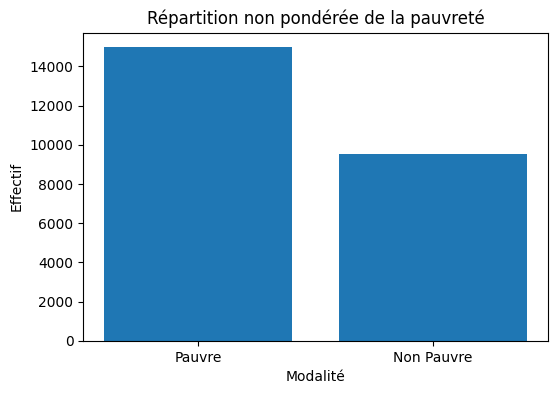

nivie,Non Pauvre,Pauvre
milieu,,
Urbain,50.421026,49.578974
Rural,33.549122,66.450878


,milieu,taux_pauvrete_pondere
0,Urbain,0.486031
1,Rural,0.651941


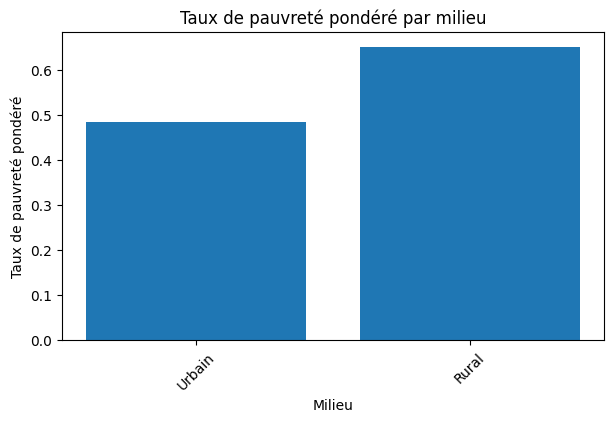

In [17]:
# Graphique simple de la répartition de la cible
freq = df_analysis[TARGET_RAW].value_counts(dropna=False)

plt.figure(figsize=(6, 4))
plt.bar(freq.index.astype(str), freq.values)
plt.title("Répartition non pondérée de la pauvreté")
plt.xlabel("Modalité")
plt.ylabel("Effectif")
plt.show()

# Exemple de tableau croisé par milieu de résidence
if "milieu" in df_analysis.columns:
    tableau_milieu = pd.crosstab(df_analysis["milieu"], df_analysis[TARGET_RAW], normalize="index") * 100
    display(tableau_milieu)

# Graphique de la pauvreté pondérée par milieu si disponible
if "milieu" in df_analysis.columns:
    pauv_milieu = (
        df_analysis.groupby("milieu")
        .apply(lambda g: weighted_proportion(g[TARGET_BIN], g["poids_normalise"]))
        .rename("taux_pauvrete_pondere")
        .reset_index()
    )
    display(pauv_milieu)

    plt.figure(figsize=(7, 4))
    plt.bar(pauv_milieu["milieu"].astype(str), pauv_milieu["taux_pauvrete_pondere"])
    plt.title("Taux de pauvreté pondéré par milieu")
    plt.xlabel("Milieu")
    plt.ylabel("Taux de pauvreté pondéré")
    plt.xticks(rotation=45)
    plt.show()


## 14. Préparation des tests statistiques

On sépare ici les variables explicatives selon leur nature :
- numériques
- catégorielles

Cette distinction est importante car les tests statistiques ne sont pas les mêmes selon le type de variable.

In [18]:
# ==========================================================
# 14. IDENTIFICATION NUMERIQUE / CATEGORIELLE
# ==========================================================
numeric_features = []
categorical_features = []

for col in feature_cols:
    if col not in df_analysis.columns:
        continue
    if pd.api.types.is_numeric_dtype(df_analysis[col]):
        numeric_features.append(col)
    else:
        categorical_features.append(col)

print("Variables numériques :")
print(numeric_features)

print("\nVariables catégorielles :")
print(categorical_features)

Variables numériques :
['hage', 'hhsize', 'ratio_dependance', 'part_ayant_compte_bancaire']

Variables catégorielles :
['hgender', 'hmar', 'hreligion', 'heduc', 'hactiv12m', 'hbranch', 'hcsp', 'handig', 'typmen', 'milieu', 'logem', 'elec_ac', 'toilet', 'telpor']


## 15. Tests statistiques sur variables numériques

Comme la cible est binaire (pauvre / non pauvre), on compare les moyennes des variables numériques entre les deux groupes à l’aide d’un **test t de Student**.

L’objectif est d’identifier les variables quantitatives qui diffèrent significativement entre ménages pauvres et non pauvres.

In [19]:
# ==========================================================
# 15. TESTS SUR VARIABLES NUMERIQUES
# ==========================================================
results_num_tests = []

for col in numeric_features:
    tmp = df_analysis[[TARGET_BIN, col]].dropna()
    if tmp.shape[0] >= 10:
        g0 = tmp.loc[tmp[TARGET_BIN] == 0, col]
        g1 = tmp.loc[tmp[TARGET_BIN] == 1, col]

        if len(g0) >= 5 and len(g1) >= 5:
            stat, pvalue = stats.ttest_ind(g0, g1, equal_var=False, nan_policy="omit")
            results_num_tests.append({
                "variable": col,
                "moyenne_non_pauvre": g0.mean(),
                "moyenne_pauvre": g1.mean(),
                "pvalue_ttest": pvalue,
                "n_obs": tmp.shape[0]
            })

df_num_tests = pd.DataFrame(results_num_tests).sort_values("pvalue_ttest")
display(df_num_tests)

,variable,moyenne_non_pauvre,moyenne_pauvre,pvalue_ttest,n_obs
1,hhsize,3.876636,5.510486,0.000000,24521
2,ratio_dependance,0.800350,1.423831,0.000000,23922
3,part_ayant_compte_bancaire,0.166770,0.041038,0.000000,24521
0,hage,42.683599,43.044753,0.057237,24519


## 16. Tests statistiques sur variables catégorielles

Pour les variables qualitatives, on utilise ici un **test du Khi-deux d’indépendance**.

L’objectif est de voir si la répartition des modalités d’une variable explicative dépend du statut de pauvreté.

In [20]:
# ==========================================================
# 16. TESTS SUR VARIABLES CATEGORIELLES
# ==========================================================
results_cat_tests = []

for col in categorical_features:
    tmp = df_analysis[[TARGET_RAW, col]].dropna()
    if tmp[col].nunique() >= 2 and tmp[TARGET_RAW].nunique() == 2:
        contingency = pd.crosstab(tmp[col], tmp[TARGET_RAW])
        if contingency.shape[0] >= 2 and contingency.shape[1] == 2:
            chi2, pvalue, dof, expected = stats.chi2_contingency(contingency)
            results_cat_tests.append({
                "variable": col,
                "chi2": chi2,
                "pvalue": pvalue,
                "ddl": dof
            })

df_cat_tests = pd.DataFrame(results_cat_tests).sort_values("pvalue")
display(df_cat_tests)

,variable,chi2,pvalue,ddl
8,typmen,1985.134765,0.000000e+00,5
12,toilet,1405.369144,1.431213e-307,1
5,hbranch,1317.687697,6.861019e-276,11
11,elec_ac,1239.607849,1.504956e-271,1
3,heduc,1220.136753,3.134515e-264,3
13,telpor,885.378239,1.480624e-194,1
10,logem,863.880438,6.045262e-187,3
1,hmar,872.085106,4.065791e-185,6
6,hcsp,786.867784,1.372569e-162,10
9,milieu,637.712934,1.050377e-140,1


## 17. Matrice de corrélation avant modélisation

Avant d’entraîner les modèles, on examine ici la corrélation entre la cible binaire et les variables explicatives numériques retenues.

L’objectif est de :
- repérer les variables les plus liées à la pauvreté ;
- détecter d’éventuelles redondances entre variables explicatives ;
- guider le choix final des variables avant estimation.


Matrice de corrélation :


,pauvre_bin,hage,hhsize,ratio_dependance,part_ayant_compte_bancaire
pauvre_bin,1.000000,0.012409,0.328508,0.280050,-0.307149
hage,0.012409,1.000000,0.118161,-0.048462,0.002311
hhsize,0.328508,0.118161,1.000000,0.390978,-0.140001
ratio_dependance,0.280050,-0.048462,0.390978,1.000000,-0.216414
part_ayant_compte_bancaire,-0.307149,0.002311,-0.140001,-0.216414,1.000000


Variables les plus corrélées à la cible :


,variable,correlation_avec_cible
0,hhsize,0.328508
1,part_ayant_compte_bancaire,-0.307149
2,ratio_dependance,0.280050
3,hage,0.012409


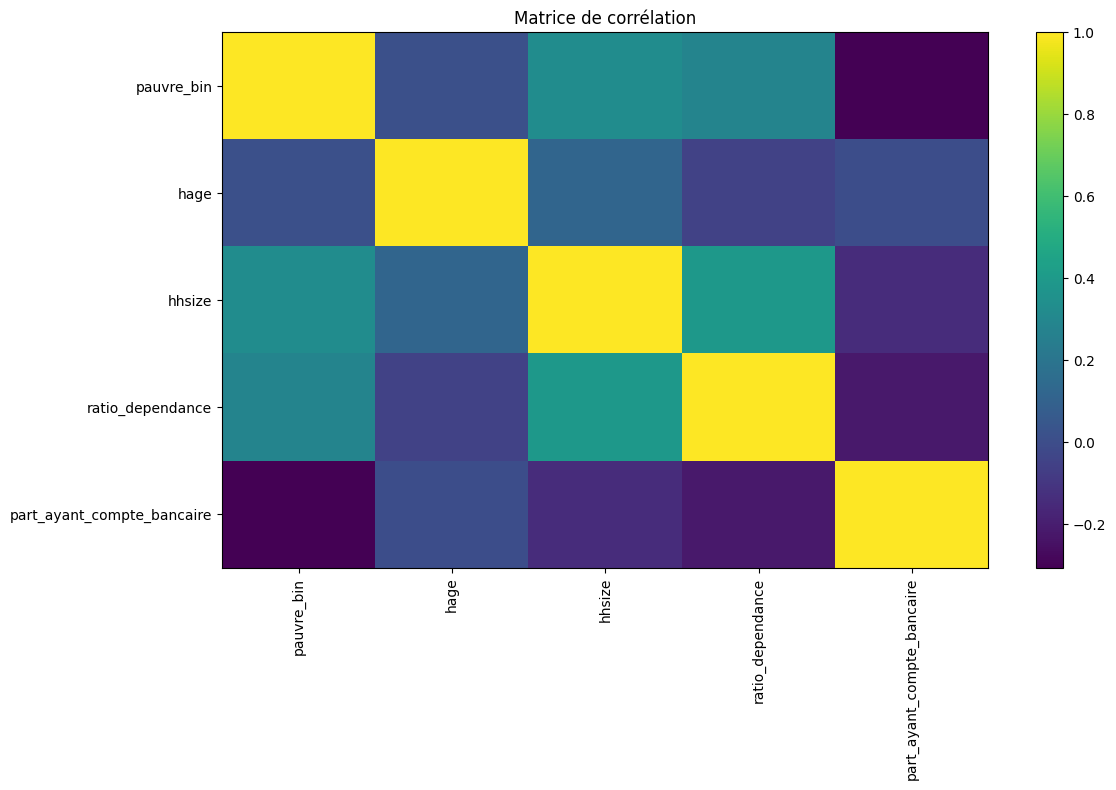

In [21]:
# ==========================================================
# 17. MATRICE DE CORRELATION AVANT MODELISATION
# ==========================================================
corr_features = [
    c for c in feature_cols
    if c in df_analysis.columns and pd.api.types.is_numeric_dtype(df_analysis[c])
]

corr_cols = [TARGET_BIN] + corr_features
corr_df = df_analysis[corr_cols].copy()

correlation_matrix = corr_df.corr(numeric_only=True)

print("Matrice de corrélation :")
display(correlation_matrix)

if TARGET_BIN in correlation_matrix.columns:
    corr_with_target = (
        correlation_matrix[TARGET_BIN]
        .drop(labels=[TARGET_BIN], errors="ignore")
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .rename("correlation_avec_cible")
        .reset_index()
        .rename(columns={"index": "variable"})
    )
    print("Variables les plus corrélées à la cible :")
    display(corr_with_target)

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("Matrice de corrélation")
plt.tight_layout()
plt.show()


## 18. Construction de la base de modélisation

On crée ici la base finale utilisée par les modèles :

- la cible binaire ;
- les poids normalisés ;
- les variables explicatives retenues après nettoyage.

À ce stade, les variables supprimées à la demande (`part_hommes`, `part_femmes`, `age_moyen_membres`) ne sont plus envoyées dans les modèles.


In [22]:
# ==========================================================
# 18. BASE FINALE DE MODELISATION
# ==========================================================
model_df = df_analysis[[TARGET_BIN, "poids_normalise"] + feature_cols].copy()
model_df = model_df[model_df[TARGET_BIN].notna()].copy()

# ----------------------------------------------------------
# Référence souhaitée pour hcsp : "Sans emploi/inactif"
# ----------------------------------------------------------
if "hcsp" in model_df.columns:
    hcsp_reference = "Sans emploi/inactif"
    hcsp_series = model_df["hcsp"].astype("string").str.strip()

    # Harmonisation légère des libellés pour capter les variantes fréquentes
    hcsp_series = hcsp_series.replace({
        "Sans emploi / inactif": hcsp_reference,
        "Sans emploi /inactif": hcsp_reference,
        "Sans emploi/ inactif": hcsp_reference,
        "sans emploi/inactif": hcsp_reference
    })

    other_hcsp_categories = [c for c in pd.unique(hcsp_series.dropna()) if c != hcsp_reference]
    model_df["hcsp"] = pd.Categorical(
        hcsp_series,
        categories=[hcsp_reference] + sorted(other_hcsp_categories),
        ordered=True
    )

X = model_df[feature_cols].copy()
y = model_df[TARGET_BIN].copy().astype(int)
sample_weight = model_df["poids_normalise"].copy()

print("Dimensions X :", X.shape)
print("Dimensions y :", y.shape)
print("\nRépartition de la cible :")
print(y.value_counts())
print("\nSomme des poids normalisés :", sample_weight.sum())

if "hcsp" in X.columns:
    print("\nModalité de référence prévue pour hcsp :", X["hcsp"].cat.categories[0])


Dimensions X : (24521, 18)
Dimensions y : (24521,)

Répartition de la cible :
pauvre_bin
1    14972
0     9549
Name: count, dtype: int64

Somme des poids normalisés : 24520.999999999996

Modalité de référence prévue pour hcsp : Sans emploi/inactif


## 19. Séparation apprentissage / test

On découpe les données en deux parties :

- **train** : pour entraîner les modèles ;
- **test** : pour évaluer leurs performances sur des données non vues.

On conserve ici les poids normalisés afin de les utiliser dans tous les modèles.


In [23]:
# ==========================================================
# 19. TRAIN / TEST SPLIT
# ==========================================================
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, sample_weight,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Combinaison : poids d'enquête + correction du déséquilibre des classes
w_train_combined, class_weights_train = combine_weights(w_train, y_train)
w_test_combined, class_weights_test = combine_weights(w_test, y_test)

print("Train :", X_train.shape)
print("Test  :", X_test.shape)
print("\nPoids de classes calculés sur le train :")
print(class_weights_train)


Train : (19616, 18)
Test  : (4905, 18)

Poids de classes calculés sur le train :
{1: np.float64(0.818902897219671), 0: np.float64(1.283937688179081)}


## 20. Prétraitement des variables

Les modèles ne gèrent pas tous les variables de la même manière.

On prépare donc :

- les variables numériques : imputation par la médiane puis standardisation ;
- les variables catégorielles : imputation par la modalité la plus fréquente puis encodage.

Ce prétraitement sera appliqué de façon identique à tous les modèles.


## 21. Entraînement et comparaison des modèles

Chaque modèle est :

1. entraîné sur les données d’apprentissage ;
2. pondéré avec les poids d’enquête normalisés ;
3. ajusté pour le déséquilibre des classes via une pondération complémentaire ;
4. évalué sur l’échantillon test.

On compare ensuite les performances obtenues.


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
import numpy as np

# 1. Identifier les colonnes par type
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# 2. Définir explicitement les catégories de référence pour l'encodage
encoder_categories = []
for col in categorical_features:
    series = X_train[col]

    if col == "hcsp":
        hcsp_reference = "Sans emploi/inactif"
        series = series.astype("string").str.strip().replace({
            "Sans emploi / inactif": hcsp_reference,
            "Sans emploi /inactif": hcsp_reference,
            "Sans emploi/ inactif": hcsp_reference,
            "sans emploi/inactif": hcsp_reference
        })
        uniques = [x for x in pd.unique(series.dropna()) if x != hcsp_reference]
        categories = [hcsp_reference] + sorted(uniques)
    else:
        categories = sorted(pd.unique(series.dropna()))

    encoder_categories.append(categories)

# 3. Créer les transformateurs pour chaque type de donnée
# Pour le numérique : Imputer (médiane) + Standardisation
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pour le catégoriel : Imputer (valeur la plus fréquente) + Encodage (0/1)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('OneHotEncoder', OneHotEncoder(
        categories=encoder_categories,
        drop='first',
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# 4. Combiner les deux dans un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# 5. Définir les modèles dans le dictionnaire avec le préprocesseur inclus
models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingClassifier(random_state=42))
    ])
}

# 6. ENTRAINEMENT ET COMPARAISON
results = []
fitted_models = {}

# Nettoyage des poids (au cas où)
w_train_clean = w_train_combined.fillna(1.0).values if hasattr(w_train_combined, 'fillna') else w_train_combined

for name, pipe in models.items():
    try:
        fitted_pipe = pipe.fit(X_train, y_train, model__sample_weight=w_train_clean)
        fitted_models[name] = fitted_pipe

        y_pred = fitted_pipe.predict(X_test)
        y_prob = fitted_pipe.predict_proba(X_test)[:, 1] if hasattr(fitted_pipe, "predict_proba") else None

        results.append({
            "modele": name,
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
            "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
        })
    except Exception as e:
        print(f"Erreur avec {name} : {e}")

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df)

if "hcsp" in categorical_features:
    idx_hcsp = list(categorical_features).index("hcsp")
    print("Référence utilisée pour hcsp :", encoder_categories[idx_hcsp][0])


,modele,accuracy,precision,recall,f1,ROC_AUC
0,Gradient Boosting,0.740877,0.785430,0.791987,0.788695,0.796558
1,Logistic Regression,0.726606,0.782638,0.764608,0.773518,0.789584
2,Random Forest,0.724159,0.742183,0.840067,0.788097,0.756129


Référence utilisée pour hcsp : Sans emploi/inactif


## 22. Résumé du modèle logistique de référence

Cette section produit un **tableau d’estimation interprétable** pour le modèle logistique.  
L’objectif n’est pas ici de résumer les modèles d’arbres, mais de disposer d’un tableau de coefficients exploitable dans le mémoire.

On procède de la manière suivante :

1. récupération du pipeline **Logistic Regression** déjà entraîné ;
2. transformation des variables avec le préprocesseur ajusté ;
3. reconstruction des noms des variables après encodage ;
4. estimation d’un **GLM binomial pondéré** avec `statsmodels` ;
5. affichage d’un tableau contenant :
   - les coefficients ;
   - les erreurs standards ;
   - les statistiques de test ;
   - les p-values ;
   - les intervalles de confiance à 95 %.

Ce tableau sert de base à l’interprétation économétrique des résultats.

In [25]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder
from IPython.display import display, HTML

# ==========================================================
# TABLEAU FINAL AVEC REFERENCES + FORMATAGE CORRECT
# ==========================================================

# 1. Pipeline logistique entraîné
logistic_pipe = fitted_models["Logistic Regression"]
preprocessor_fitted = logistic_pipe.named_steps["preprocessor"]

# 2. Transformation des données
X_train_transformed = preprocessor_fitted.transform(X_train)

# 3. Variables numériques
num_features = list(numeric_features)

# 4. Récupération du OneHotEncoder
cat_transformer = preprocessor_fitted.named_transformers_["cat"]

encoder = None
for _, step_obj in cat_transformer.named_steps.items():
    if isinstance(step_obj, OneHotEncoder):
        encoder = step_obj
        break

if encoder is None:
    raise ValueError("OneHotEncoder introuvable")

# 5. Variables catégorielles encodées
cat_features = encoder.get_feature_names_out(categorical_features)

# 6. Reconstruction du DataFrame pour statsmodels
feature_names = num_features + list(cat_features)
X_train_sm = pd.DataFrame(X_train_transformed, columns=feature_names, index=X_train.index)

# 7. Ajouter constante
X_train_sm = sm.add_constant(X_train_sm, has_constant="add")

# 8. Modèle logistique pondéré
logit_model = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial(),
    freq_weights=w_train_clean
).fit()

# 9. Tableau résumé brut
summary_table = pd.DataFrame({
    "Facteurs explicatifs": logit_model.params.index,
    "Coefficient": logit_model.params.values,
    "Erreur standard": logit_model.bse.values,
    "z": logit_model.tvalues.values,
    "P>|z|": logit_model.pvalues.values,
    "IC 95% bas": logit_model.conf_int()[0].values,
    "IC 95% haut": logit_model.conf_int()[1].values
})

summary_table = summary_table[summary_table["Facteurs explicatifs"] != "const"].copy()

# ==========================================================
# 10. TABLEAU FINAL AVEC REFERENCES
# ==========================================================
final_rows = []
categories_dict = dict(zip(categorical_features, encoder.categories_))

# Variables numériques
for var in num_features:
    row = summary_table[summary_table["Facteurs explicatifs"] == var]
    if not row.empty:
        row_dict = row.iloc[0].to_dict()
        row_dict["Facteurs explicatifs"] = f"<b>{var}</b>"
        final_rows.append(row_dict)

# Variables catégorielles
for var in categorical_features:
    # Titre du bloc
    final_rows.append({
        "Facteurs explicatifs": f"<b>{var}</b>",
        "Coefficient": "-",
        "Erreur standard": "-",
        "z": "-",
        "P>|z|": "-",
        "IC 95% bas": "-",
        "IC 95% haut": "-"
    })

    categories = list(categories_dict[var])

    # Référence
    final_rows.append({
        "Facteurs explicatifs": f"&nbsp;&nbsp;{categories[0]} (référence)",
        "Coefficient": "-",
        "Erreur standard": "-",
        "z": "-",
        "P>|z|": "-",
        "IC 95% bas": "-",
        "IC 95% haut": "-"
    })

    # Modalités non-références
    for cat in categories[1:]:
        col_name = f"{var}_{cat}"
        row = summary_table[summary_table["Facteurs explicatifs"] == col_name]

        if not row.empty:
            row_dict = row.iloc[0].to_dict()
            row_dict["Facteurs explicatifs"] = f"&nbsp;&nbsp;{cat}"
            final_rows.append(row_dict)

# 11. DataFrame final
final_table = pd.DataFrame(final_rows)

# 12. Arrondir les colonnes numériques
for col in ["Coefficient", "Erreur standard", "z", "P>|z|", "IC 95% bas", "IC 95% haut"]:
    final_table[col] = pd.to_numeric(final_table[col], errors="coerce").round(3)

# 13. Remplacer NaN par "-"
final_table = final_table.fillna("-")

# ==========================================================
# 14. AFFICHAGE HTML CORRECT
# ==========================================================
html_table = final_table.to_html(index=False, escape=False)
display(HTML(html_table))

Facteurs explicatifs,Coefficient,Erreur standard,z,P>|z|,IC 95% bas,IC 95% haut
hage,0.144,0.02,7.289,0.0,0.105,0.183
ratio_dependance,0.43,0.021,20.663,0.0,0.389,0.471
part_ayant_compte_bancaire,-0.453,0.025,-17.934,0.0,-0.503,-0.404
hgender,-,-,-,-,-,-
Féminin (référence),-,-,-,-,-,-
Masculin,-0.118,0.077,-1.53,0.126,-0.269,0.033
hmar,-,-,-,-,-,-
Célibataire (référence),-,-,-,-,-,-
Divorcé(e),0.237,0.123,1.926,0.054,-0.004,0.479
Marié(e) monogame,0.085,0.098,0.868,0.385,-0.107,0.278


## 23. Matrices de confusion et rapports de classification

Cette section permet d’aller au-delà des scores globaux.

Elle montre, pour chaque modèle :

- les bonnes classifications ;
- les erreurs entre ménages pauvres et non pauvres ;
- le rapport de classification détaillé.


In [26]:
# ==========================================================
# 22. MATRICES DE CONFUSION
# ==========================================================
for name, fitted_pipe in fitted_models.items():
    y_pred = fitted_pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print("Matrice de confusion :")
    print(cm)
    print("\nRapport de classification :")
    print(classification_report(y_test, y_pred, zero_division=0))



Logistic Regression
Matrice de confusion :
[[1274  636]
 [ 705 2290]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.64      0.67      0.66      1910
           1       0.78      0.76      0.77      2995

    accuracy                           0.73      4905
   macro avg       0.71      0.72      0.71      4905
weighted avg       0.73      0.73      0.73      4905


Random Forest
Matrice de confusion :
[[1036  874]
 [ 479 2516]]

Rapport de classification :
              precision    recall  f1-score   support

           0       0.68      0.54      0.60      1910
           1       0.74      0.84      0.79      2995

    accuracy                           0.72      4905
   macro avg       0.71      0.69      0.70      4905
weighted avg       0.72      0.72      0.72      4905


Gradient Boosting
Matrice de confusion :
[[1262  648]
 [ 623 2372]]

Rapport de classification :
              precision    recall  f1-score   support


## 24. Validation croisée

Pour compléter l’évaluation sur l’échantillon test, on utilise une validation croisée stratifiée à 5 plis.

À chaque pli :

- le modèle est réentraîné ;
- les poids d’enquête sont conservés ;
- le déséquilibre des classes est à nouveau pris en compte sur le pli d’apprentissage.


In [27]:
# ==========================================================
# 23. VALIDATION CROISEE
# ==========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, pipe in models.items():
    fold_scores = []
    erreurs = []

    for train_idx, valid_idx in cv.split(X, y):
        X_tr, X_val = X.iloc[train_idx], X.iloc[valid_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[valid_idx]
        w_tr, w_val = sample_weight.iloc[train_idx], sample_weight.iloc[valid_idx]

        try:
            w_tr_combined, _ = combine_weights(w_tr, y_tr)
            fitted_pipe = fit_pipeline_with_weights(pipe, X_tr, y_tr, w_tr_combined)

            if hasattr(fitted_pipe, "predict_proba"):
                y_prob_val = fitted_pipe.predict_proba(X_val)[:, 1]
            else:
                y_prob_val = fitted_pipe.predict(X_val).astype(float)

            score = roc_auc_score(y_val, y_prob_val)
            fold_scores.append(score)
        except Exception as e:
            erreurs.append(str(e))

    cv_results.append({
        "modele": name,
        "CV_ROC_AUC_moyen": np.mean(fold_scores) if fold_scores else np.nan,
        "CV_ROC_AUC_std": np.std(fold_scores) if fold_scores else np.nan,
        "n_folds_valides": len(fold_scores),
        "erreur": " | ".join(sorted(set(erreurs))) if erreurs else ""
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_ROC_AUC_moyen", ascending=False)
display(cv_results_df)


,modele,CV_ROC_AUC_moyen,CV_ROC_AUC_std,n_folds_valides,erreur
2,Gradient Boosting,0.784981,0.005463,5,
0,Logistic Regression,0.780546,0.006320,5,
1,Random Forest,0.754905,0.002998,5,


## 25. Importance des variables dans le Random Forest

Les modèles d’arbres offrent une mesure d’importance des variables.

Cela permet d’identifier les facteurs qui contribuent le plus à la prédiction de la pauvreté dans le meilleur ensemble de variables retenu.


,variable,importance
0,num__hage,0.185184
1,num__ratio_dependance,0.150907
2,num__part_ayant_compte_bancaire,0.075867
57,cat__telpor_Oui,0.026804
46,cat__typmen_Menage unipersonnel,0.026184
20,cat__heduc_Secondaire,0.024827
56,cat__toilet_Oui,0.022393
12,cat__hreligion_Catholique,0.021318
19,cat__heduc_Primaire,0.020692
53,cat__logem_Proprietaire sans titre,0.020650


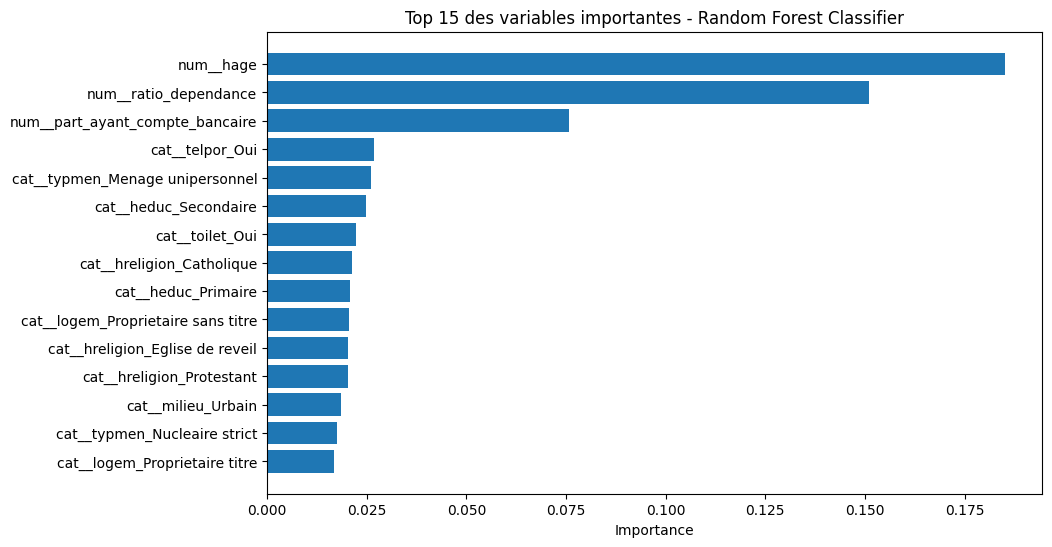

In [28]:
# ==========================================================
# 26. IMPORTANCE DES VARIABLES
# ==========================================================
rf_pipe = fitted_models["Random Forest"]
rf_model = rf_pipe.named_steps["model"]
feat_names = rf_pipe.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "variable": feat_names,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 6))
top_imp = importance_df.head(15).sort_values("importance")
plt.barh(top_imp["variable"], top_imp["importance"])
plt.title("Top 15 des variables importantes - Random Forest Classifier")
plt.xlabel("Importance")
plt.show()


## 26. Tableau final de synthèse

On regroupe ici les performances des modèles de machine learning retenus afin d’identifier le meilleur modèle selon le critère choisi.


In [29]:
# ==========================================================
# 27. TABLEAU FINAL DE SYNTHESE
# ==========================================================
final_results = results_df.merge(cv_results_df, on="modele", how="left")
final_results = final_results.sort_values("ROC_AUC", ascending=False)
display(final_results)


,modele,accuracy,precision,recall,f1,ROC_AUC,CV_ROC_AUC_moyen,CV_ROC_AUC_std,n_folds_valides,erreur
0,Gradient Boosting,0.740877,0.785430,0.791987,0.788695,0.796558,0.784981,0.005463,5,
1,Logistic Regression,0.726606,0.782638,0.764608,0.773518,0.789584,0.780546,0.006320,5,
2,Random Forest,0.724159,0.742183,0.840067,0.788097,0.756129,0.754905,0.002998,5,


## 27. Sauvegarde automatique du meilleur modèle

Une fois la comparaison terminée, le meilleur modèle est :

- sélectionné selon le critère `ROC_AUC` ;
- réentraîné sur l’ensemble des données disponibles ;
- sauvegardé dans le dossier `outputs/models/`.

Le notebook enregistre à la fois :

- le **pipeline complet** prêt à être réutilisé ;
- un **bundle** contenant le modèle et ses métadonnées ;
- le **tableau des performances** au format CSV.

Cette étape facilite la réutilisation du modèle dans l’application Streamlit et améliore la reproductibilité du projet.

In [30]:
# ==========================================================
# 28. SAUVEGARDE AUTOMATIQUE DU MEILLEUR MODELE
# ==========================================================
import os
import joblib
from datetime import datetime

# 1) Choisir le critère de sélection
CRITERE_SELECTION = "ROC_AUC"

# 2) Vérifier que le tableau des résultats existe
if "results_df" not in globals():
    raise ValueError("results_df n'existe pas. Exécute d'abord la comparaison des modèles.")

# 3) Classer les modèles du meilleur au moins bon
results_df = results_df.sort_values(CRITERE_SELECTION, ascending=False).reset_index(drop=True)

# 4) Nom du meilleur modèle
best_model_name = results_df.loc[0, "modele"]
print("Meilleur modèle sélectionné :", best_model_name)

# 5) Récupérer le pipeline correspondant
best_model = models[best_model_name]

# 6) Réentraîner le meilleur modèle sur l'ensemble des données
sample_weight_combined, class_weights_full = combine_weights(sample_weight, y)
best_model = fit_pipeline_with_weights(best_model, X, y, sample_weight_combined)

# 7) Créer un dossier de sauvegarde
models_dir = "outputs/models"
os.makedirs(models_dir, exist_ok=True)

# 8) Horodatage pour versionner les fichiers
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# 9) Fichiers de sortie
model_path = os.path.join(models_dir, f"best_model_{best_model_name}_{timestamp}.pkl")
bundle_path = os.path.join(models_dir, f"best_model_bundle_{best_model_name}_{timestamp}.pkl")
results_path = os.path.join(models_dir, f"model_results_{timestamp}.csv")

# 10) Sauvegarde du modèle seul
joblib.dump(best_model, model_path)

# 11) Sauvegarde complète : modèle + métadonnées utiles
bundle = {
    "model_name": best_model_name,
    "selection_metric": CRITERE_SELECTION,
    "model": best_model,
    "feature_cols": feature_cols,
    "target_raw": TARGET_RAW,
    "target_bin": TARGET_BIN,
    "weight_var": WEIGHT_VAR,
    "hh_size_var": HH_SIZE_VAR,
    "id_welfare_indiv": ID_WELFARE_INDIV,
    "id_menage": ID_MENAGE,
    "class_weights_full": class_weights_full,
    "results_df": results_df,
    "cv_results_df": cv_results_df
}
joblib.dump(bundle, bundle_path)

# 12) Sauvegarde du tableau de résultats
final_results.to_csv(results_path, index=False, encoding="utf-8-sig")

print("Modèle sauvegardé :", model_path)
print("Bundle complet sauvegardé :", bundle_path)
print("Résultats sauvegardés :", results_path)


Meilleur modèle sélectionné : Gradient Boosting
Modèle sauvegardé : outputs/models\best_model_Gradient Boosting_20260325_234434.pkl
Bundle complet sauvegardé : outputs/models\best_model_bundle_Gradient Boosting_20260325_234434.pkl
Résultats sauvegardés : outputs/models\model_results_20260325_234434.csv


# Conclusion méthodologique

## Ce que ce notebook a permis de faire

- construire une base ménage à partir de plusieurs fichiers ;
- créer une cible binaire de pauvreté ;
- calculer des poids normalisés selon la formule demandée ;
- ajouter le ratio de dépendance parmi les variables explicatives ;
- enrichir l’analyse descriptive ;
- examiner la matrice de corrélation avant modélisation ;
- entraîner plusieurs modèles de classification pondérés ;
- corriger le déséquilibre des classes dans tous les modèles ;
- comparer les performances et sauvegarder automatiquement le meilleur modèle.